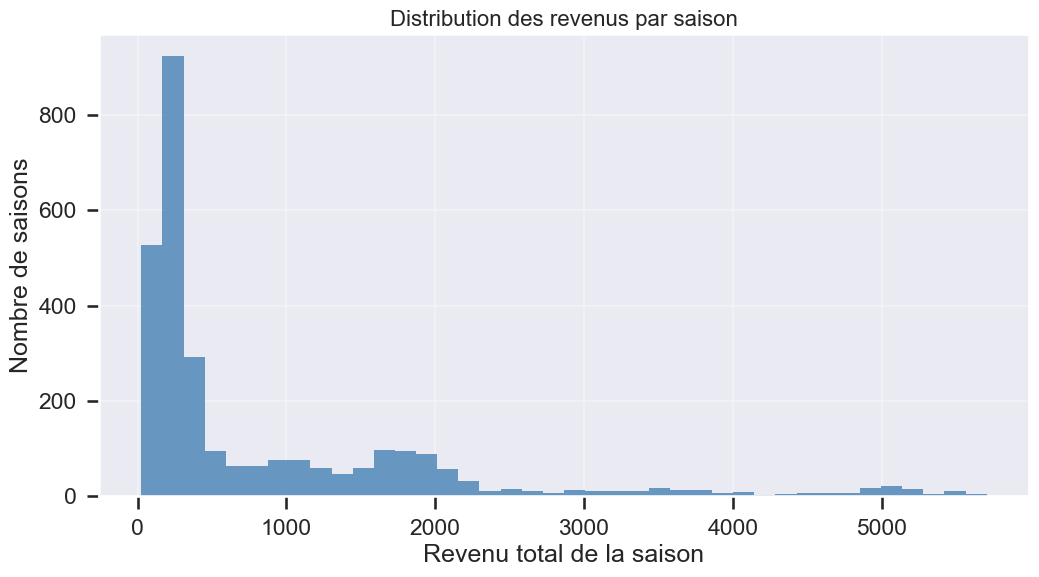

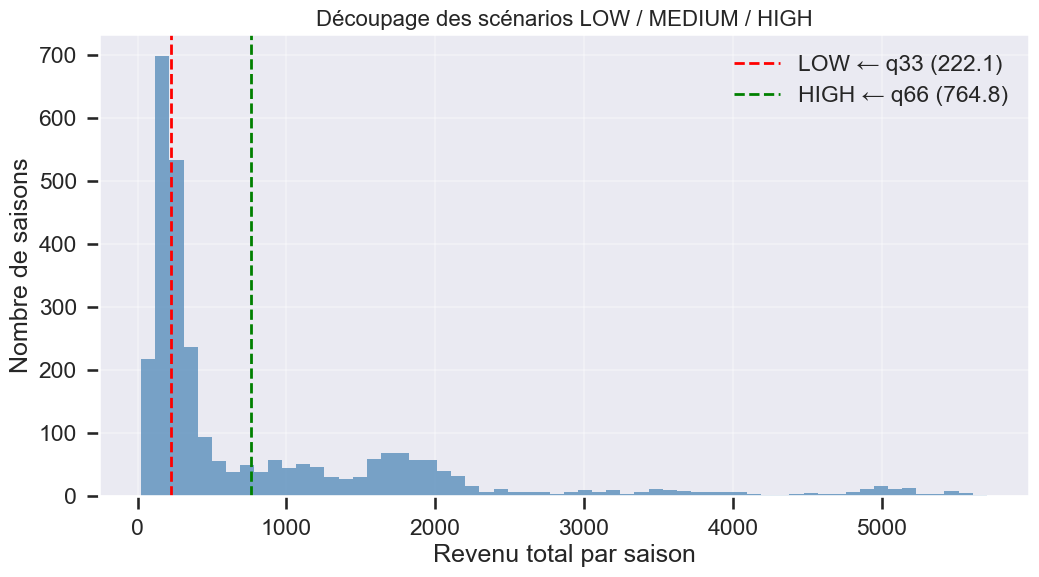

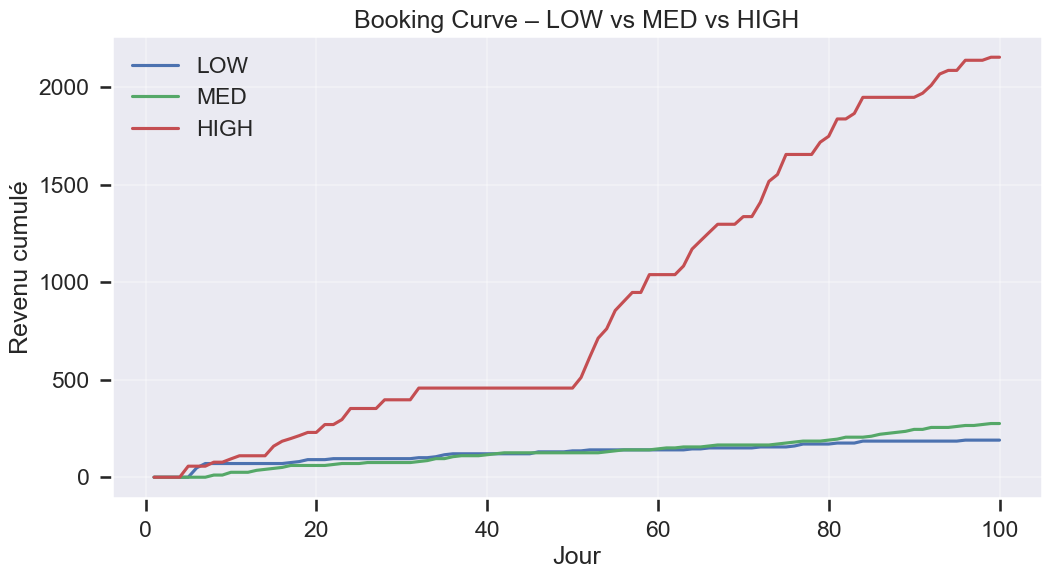

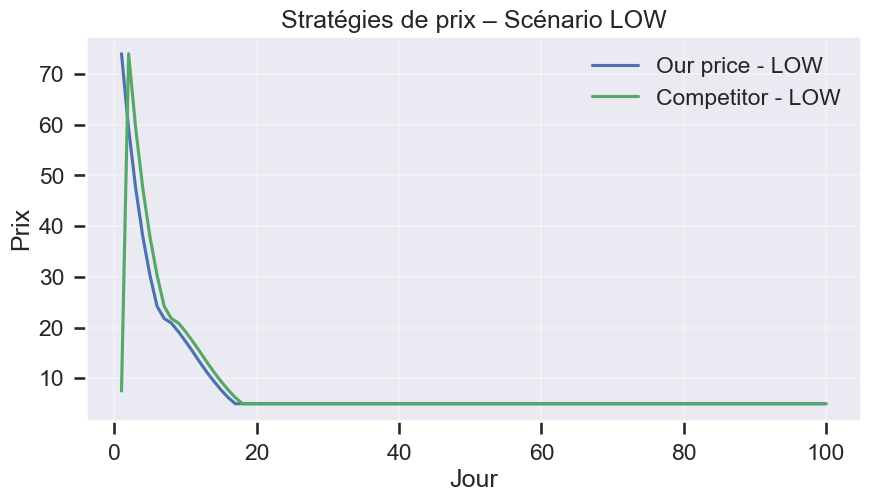

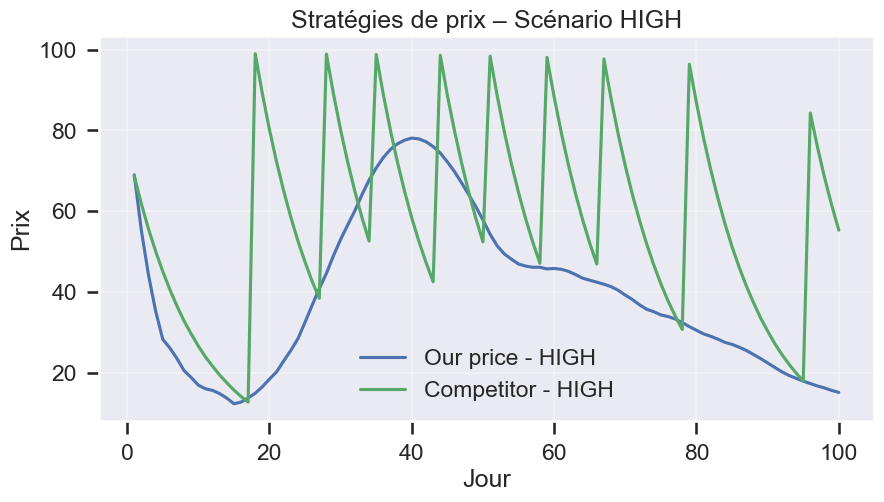

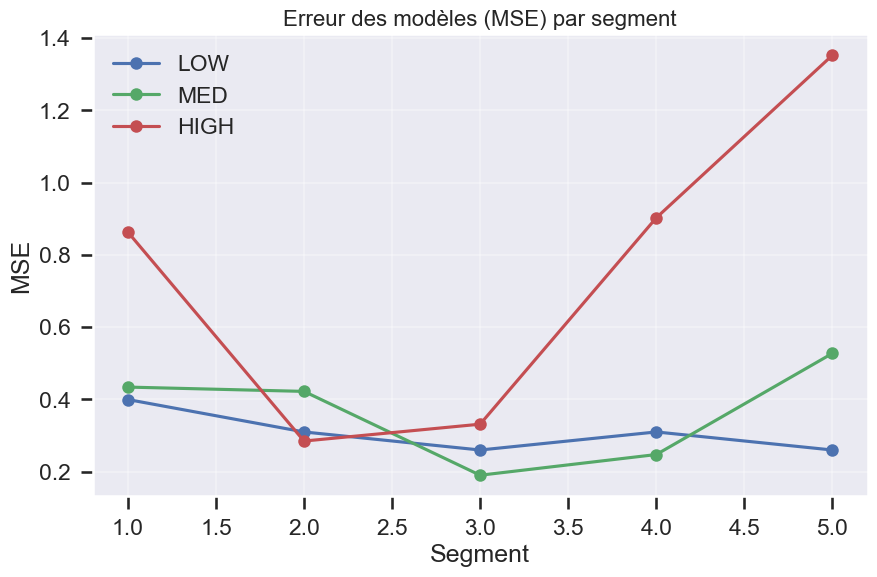

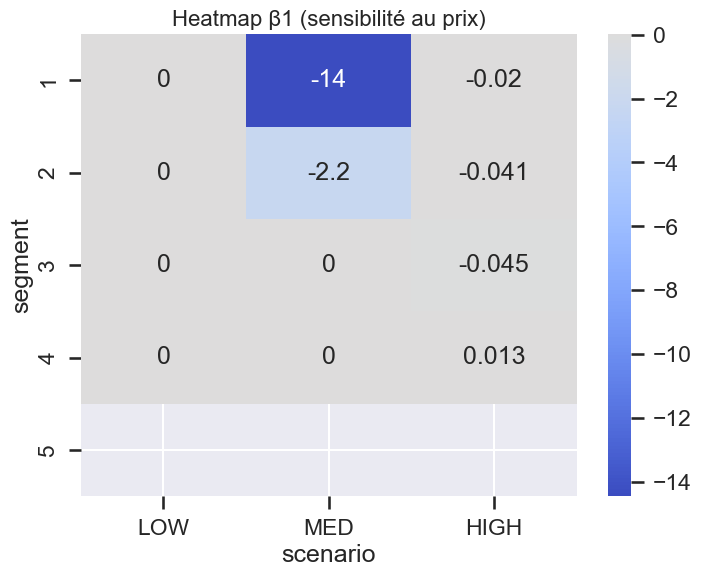

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
#  DISTRIBUTION GLOBALE DES REVENUS
# ============================================================================
plt.figure(figsize=(12,6))
plt.hist(revenus_par_saison["revenue"], bins=40, alpha=0.8, color="steelblue")
plt.title("Distribution des revenus par saison", fontsize=16)
plt.xlabel("Revenu total de la saison")
plt.ylabel("Nombre de saisons")
plt.grid(alpha=0.3)
plt.show()


# ============================================================================
# 2) DÉCOUPAGE LOW / MED / HIGH AVEC SEUILS (q33, q66)
# ============================================================================
q33 = revenus_par_saison["revenue"].quantile(0.33)
q66 = revenus_par_saison["revenue"].quantile(0.66)

plt.figure(figsize=(12,6))
plt.hist(revenus_par_saison["revenue"], bins=60, alpha=0.7, color="steelblue")

plt.axvline(q33, color="red", linestyle="--", linewidth=2, label=f"LOW ← q33 ({q33:.1f})")
plt.axvline(q66, color="green", linestyle="--", linewidth=2, label=f"HIGH ← q66 ({q66:.1f})")

plt.title("Découpage des scénarios LOW / MEDIUM / HIGH", fontsize=16)
plt.xlabel("Revenu total par saison")
plt.ylabel("Nombre de saisons")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================================
# 3) BOOKING CURVES LOW / MED / HIGH
# ============================================================================
plt.figure(figsize=(12,6))
plt.plot(LOW["day"], LOW["cum_revenue_local"], label="LOW")
plt.plot(MED["day"], MED["cum_revenue_local"], label="MED")
plt.plot(HIGH["day"], HIGH["cum_revenue_local"], label="HIGH")

plt.title("Booking Curve – LOW vs MED vs HIGH")
plt.xlabel("Jour")
plt.ylabel("Revenu cumulé")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================================
# 4) PRIX – LOW
# ============================================================================
plt.figure(figsize=(10,5))
plt.plot(LOW["day"], LOW["our_price"], label="Our price - LOW")
plt.plot(LOW["day"], LOW["competitor_price"], label="Competitor - LOW")
plt.title("Stratégies de prix – Scénario LOW")
plt.xlabel("Jour")
plt.ylabel("Prix")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================================
# 5) PRIX – HIGH
# ============================================================================
plt.figure(figsize=(10,5))
plt.plot(HIGH["day"], HIGH["our_price"], label="Our price - HIGH")
plt.plot(HIGH["day"], HIGH["competitor_price"], label="Competitor - HIGH")
plt.title("Stratégies de prix – Scénario HIGH")
plt.xlabel("Jour")
plt.ylabel("Prix")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================================
# 6) MSE PAR SEGMENT
# ============================================================================
plt.figure(figsize=(10,6))
plt.plot(segments_LOW["segment"], segments_LOW["mse"], marker="o", label="LOW")
plt.plot(segments_MED["segment"], segments_MED["mse"], marker="o", label="MED")
plt.plot(segments_HIGH["segment"], segments_HIGH["mse"], marker="o", label="HIGH")

plt.title("Erreur des modèles (MSE) par segment", fontsize=16)
plt.xlabel("Segment")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================================
# 7) HEATMAP DES COEFF β1 (sensibilité au prix)
# ============================================================================
β1_matrix = pd.DataFrame({
    "LOW"  : segments_LOW["beta1_our_price"],
    "MED"  : segments_MED["beta1_our_price"],
    "HIGH" : segments_HIGH["beta1_our_price"],
}, index=segments_LOW["segment"])

plt.figure(figsize=(8,6))
sns.heatmap(β1_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Heatmap β1 (sensibilité au prix)", fontsize=16)
plt.xlabel("scenario")
plt.ylabel("segment")
plt.show()
